/tmp/ipykernel_26024/3056569356.py:1: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import datasets, input_data, plotting, masking


[fetch_adhd] Dataset created in /home/john-walkey/nilearn_data/adhd
[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7781/adhd40_metadata.tgz ...
[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /home/john-walkey/nilearn_data/adhd/fbef5baff0b388a8c913a08e1d84e059/adhd40_metadata.tgz...
[fetch_adhd] .. done.

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7782/adhd40_0010042.tgz ...
[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /home/john-walkey/nilearn_data/adhd/e7ff5670bd594dcd9453e57b55d69dc9/adhd40_0010042.tgz...
[fetch_adhd] .. done.

Data shape: (176, 62546)


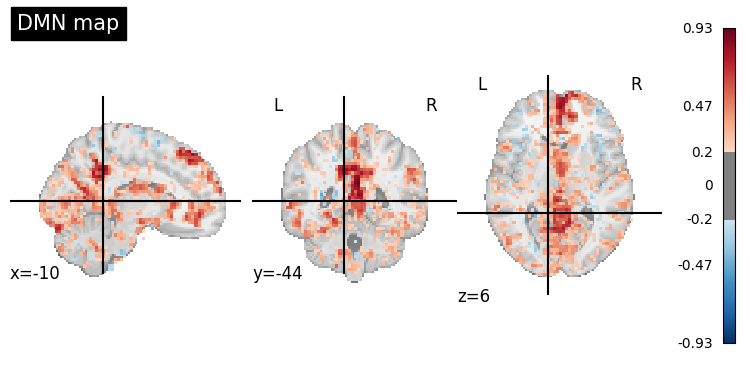

In [1]:
from nilearn import datasets, input_data, plotting, masking
from nilearn.connectome import ConnectivityMeasure
import numpy as np

# 1) Download data
adhd = datasets.fetch_adhd(n_subjects=1)
func_file = adhd.func[0]

# 2) Create a brain mask first to reduce data
masker = input_data.NiftiMasker(
    mask_strategy='epi',  # Compute mask from the data
    standardize="zscore_sample", 
    detrend=True,
    low_pass=0.1, 
    high_pass=0.01, 
    t_r=2.0,
    memory='nilearn_cache'  # Cache intermediate results
)
brain_ts = masker.fit_transform(func_file)
print(f"Data shape: {brain_ts.shape}")  # Should show (timepoints, voxels)

# 3) Extract seed time series
seed = input_data.NiftiSpheresMasker(
    seeds=[(0, -52, 26)], radius=8,
    standardize="zscore_sample", 
    detrend=True,
    low_pass=0.1, 
    high_pass=0.01, 
    t_r=2.0,
    memory='nilearn_cache'
)
seed_ts = seed.fit_transform(func_file)

# 4) Efficient correlation
corr = np.dot(brain_ts.T, seed_ts) / brain_ts.shape[0]
corr_img = masker.inverse_transform(corr.T)

plotting.plot_stat_map(corr_img, threshold=0.2, title="DMN map")
plotting.show()